# Notebook 02 — Feature Engineering & Sliding-Window Sequence Formulation

This notebook covers:
1. Adding cyclical time embeddings (Day & Year sinusoidal projections)
2. Chronological train / validation / test splitting (70 / 15 / 15 %)
3. Zero-leakage StandardScaler fitting (train set only)
4. Sliding-window tf.data.Dataset construction
5. Shape verification for all splits


## 0. Setup

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.config import (
    CLEANED_DATA_PATH, TARGET_COLS, CYCLICAL_COLS,
    ALL_FEATURE_COLS, WINDOW_LENGTH, HORIZON, BATCH_SIZE,
    TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT
)
print("✅ Imports successful")
print(f"  Target variables  : {TARGET_COLS}")
print(f"  Cyclical features : {CYCLICAL_COLS}")
print(f"  All features (D=8): {ALL_FEATURE_COLS}")
print(f"  Window length     : {WINDOW_LENGTH} hours")
print(f"  Forecast horizon  : {HORIZON} step(s)")


✅ Imports successful
  Target variables  : ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)']
  Cyclical features : ['Day_sin', 'Day_cos', 'Year_sin', 'Year_cos']
  All features (D=8): ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'Day_sin', 'Day_cos', 'Year_sin', 'Year_cos']
  Window length     : 72 hours
  Forecast horizon  : 1 step(s)


## 1. Cyclical Time Feature Engineering

In [2]:
from src.features import add_cyclical_time_features, add_calendar_features, add_lag_features

df = pd.read_csv(CLEANED_DATA_PATH, index_col=0, parse_dates=True)
df_feat = add_cyclical_time_features(df)

print("Cyclical feature columns added:")
print(df_feat[CYCLICAL_COLS].describe().round(4))


Cyclical feature columns added:
          Day_sin     Day_cos    Year_sin    Year_cos
count  70129.0000  70129.0000  70129.0000  70129.0000
mean       0.0000      0.0000      0.0000      0.0000
std        0.7071      0.7071      0.7071      0.7071
min       -1.0000     -1.0000     -1.0000     -1.0000
25%       -0.7071     -0.7071     -0.7071     -0.7071
50%        0.0000      0.0000      0.0001      0.0001
75%        0.7071      0.7071      0.7071      0.7072
max        1.0000      1.0000      1.0000      1.0000


In [3]:
# Explicit Calendar and Lag Feature Engineering
df_calendar = add_calendar_features(df)
print("Calendar features (hour, day_of_year, season):")
print(df_calendar[["hour", "day_of_year", "season"]].head())

df_lags = add_lag_features(df, target_cols=TARGET_COLS, lags=(1, 24))
lag_cols = [c for c in df_lags.columns if "lag" in c]
print("\nLag features generated:")
print(df_lags[lag_cols].head())


Calendar features (hour, day_of_year, season):
                     hour  day_of_year  season
Date Time                                     
2009-01-01 00:00:00     0            1       1
2009-01-01 01:00:00     1            1       1
2009-01-01 02:00:00     2            1       1
2009-01-01 03:00:00     3            1       1
2009-01-01 04:00:00     4            1       1

Lag features generated:
                       T_lag1  T_lag24      p_lag1  p_lag24    rh_lag1  \
Date Time                                                                
2009-01-01 00:00:00 -8.304000   -8.304  996.528000  996.528  93.780000   
2009-01-01 01:00:00 -8.304000   -8.304  996.528000  996.528  93.780000   
2009-01-01 02:00:00 -8.065000   -8.304  996.525000  996.528  93.933333   
2009-01-01 03:00:00 -8.763333   -8.304  996.745000  996.528  93.533333   
2009-01-01 04:00:00 -8.896667   -8.304  996.986667  996.528  93.200000   

                     rh_lag24   wv_lag1  wv_lag24  
Date Time                   

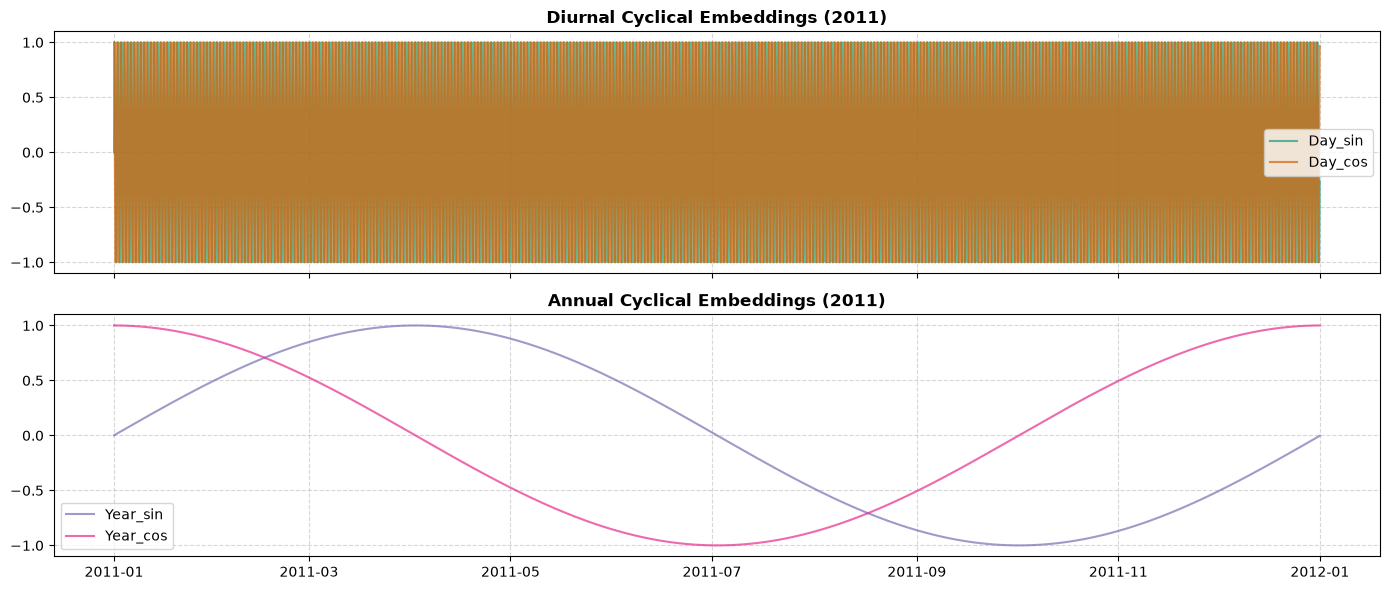

In [4]:
# Visualise cyclical projections over one year
sample = df_feat.loc["2011-01-01":"2011-12-31"]
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(sample.index, sample["Day_sin"], label="Day_sin", color="#1b9e77", alpha=0.7)
axes[0].plot(sample.index, sample["Day_cos"], label="Day_cos", color="#d95f02", alpha=0.7)
axes[0].set_title("Diurnal Cyclical Embeddings (2011)", fontweight="bold")
axes[0].legend(); axes[0].grid(True, linestyle="--", alpha=0.5)
axes[1].plot(sample.index, sample["Year_sin"], label="Year_sin", color="#7570b3", alpha=0.7)
axes[1].plot(sample.index, sample["Year_cos"], label="Year_cos", color="#e7298a", alpha=0.7)
axes[1].set_title("Annual Cyclical Embeddings (2011)", fontweight="bold")
axes[1].legend(); axes[1].grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()


## 2. Chronological Train / Validation / Test Split

In [5]:
from src.features import chronological_split

train_df, val_df, test_df = chronological_split(df_feat)

print(f"\nSplit sizes:")
print(f"  Train : {len(train_df):>7,} samples  ({len(train_df)/len(df_feat)*100:.1f}%)")
print(f"  Val   : {len(val_df):>7,} samples  ({len(val_df)/len(df_feat)*100:.1f}%)")
print(f"  Test  : {len(test_df):>7,} samples  ({len(test_df)/len(df_feat)*100:.1f}%)")


[+] Train set: 2009-01-01 00:00:00 to 2014-08-08 09:00:00 (49,090 samples, 70.0%)
[+] Val set:   2014-08-08 10:00:00 to 2015-10-20 16:00:00 (10,519 samples, 15.0%)
[+] Test set:  2015-10-20 17:00:00 to 2017-01-01 00:00:00 (10,520 samples, 15.0%)

Split sizes:
  Train :  49,090 samples  (70.0%)
  Val   :  10,519 samples  (15.0%)
  Test  :  10,520 samples  (15.0%)


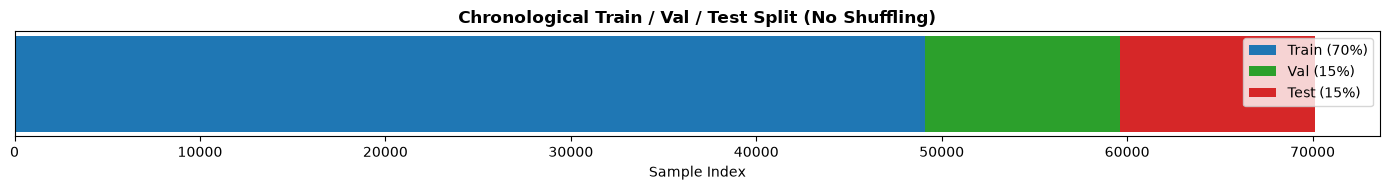

In [6]:
# Visual: Timeline of splits
fig, ax = plt.subplots(figsize=(14, 2))
ax.barh(0, len(train_df), color="#1f77b4", label=f"Train ({TRAIN_SPLIT*100:.0f}%)")
ax.barh(0, len(val_df),   left=len(train_df),                   color="#2ca02c", label=f"Val ({VAL_SPLIT*100:.0f}%)")
ax.barh(0, len(test_df),  left=len(train_df)+len(val_df),       color="#d62728", label=f"Test ({TEST_SPLIT*100:.0f}%)")
ax.set_xlabel("Sample Index"); ax.set_yticks([])
ax.set_title("Chronological Train / Val / Test Split (No Shuffling)", fontweight="bold")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


## 3. Zero-Leakage Scaling

In [7]:
from src.features import ZeroLeakagePreprocessor

preprocessor = ZeroLeakagePreprocessor()
preprocessor.fit(train_df)   # Scaler fit ONLY on train set

X_train, y_train = preprocessor.transform(train_df)
X_val,   y_val   = preprocessor.transform(val_df)
X_test,  y_test  = preprocessor.transform(test_df)

print("\nScaled array shapes:")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val  : {X_val.shape}    y_val  : {y_val.shape}")
print(f"  X_test : {X_test.shape}   y_test : {y_test.shape}")
print(f"\nX_train mean (≈0): {X_train.mean():.4f}")
print(f"X_train std  (≈1): {X_train.std():.4f}")
print(f"X_val  mean (should NOT be exactly 0): {X_val.mean():.4f}")


[+] Scalers fitted and saved to D:\AIML\Multivariate Weather Forecasting with Attention\results

Scaled array shapes:
  X_train: (49090, 8)  y_train: (49090, 4)
  X_val  : (10519, 8)    y_val  : (10519, 4)
  X_test : (10520, 8)   y_test : (10520, 4)

X_train mean (≈0): 0.0000
X_train std  (≈1): 1.0000
X_val  mean (should NOT be exactly 0): -0.0018


## 4. Sliding-Window tf.data.Dataset Construction

In [8]:
from src.sequences import create_sliding_window_dataset

train_ds = create_sliding_window_dataset(X_train, y_train, shuffle=True)
val_ds   = create_sliding_window_dataset(X_val,   y_val,   shuffle=False)
test_ds  = create_sliding_window_dataset(X_test,  y_test,  shuffle=False)

print("Dataset pipelines created:")
for name, ds in [("train_ds", train_ds), ("val_ds", val_ds), ("test_ds", test_ds)]:
    for x_b, y_b in ds.take(1):
        print(f"  {name}: X_batch={tuple(x_b.shape)},  y_batch={tuple(y_b.shape)}")


Dataset pipelines created:
  train_ds: X_batch=(128, 72, 8),  y_batch=(128, 4)
  val_ds: X_batch=(128, 72, 8),  y_batch=(128, 4)


  test_ds: X_batch=(128, 72, 8),  y_batch=(128, 4)


In [9]:
# Multi-Step Ahead Forecasting Sequence Construction Demo (e.g. 6 Hours Ahead)
multi_step_ds = create_sliding_window_dataset(X_train, y_train, multi_step=True, horizon_steps=6, batch_size=128)
for x_m, y_m in multi_step_ds.take(1):
    print(f"Multi-Step Ahead Batch X shape: {tuple(x_m.shape)}  (72 historical hours)")
    print(f"Multi-Step Ahead Batch Y shape: {tuple(y_m.shape)}  (6 forecast steps ahead x 4 targets)")


Multi-Step Ahead Batch X shape: (128, 72, 8)  (72 historical hours)
Multi-Step Ahead Batch Y shape: (128, 6, 4)  (6 forecast steps ahead x 4 targets)


## 5. Shape & Sanity Verification

In [10]:
from src.sequences import extract_arrays_for_evaluation

X_test_arr, y_test_arr = extract_arrays_for_evaluation(X_test, y_test)

print(f"Test evaluation arrays:")
print(f"  X_test_arr : {X_test_arr.shape}  — (windows, timesteps=72, features=8)")
print(f"  y_test_arr : {y_test_arr.shape}  — (windows, targets=4)")

# Quick check: inverse transform one batch to verify units
y_sample_unscaled = preprocessor.inverse_transform_targets(y_test_arr[:5])
print("\nFirst 5 test targets (physical units):")
header = f"{'T(°C)':>10} {'p(mbar)':>10} {'rh(%)':>10} {'wv(m/s)':>10}"
print(header)
for row in y_sample_unscaled:
    print(f"{row[0]:>10.2f} {row[1]:>10.2f} {row[2]:>10.2f} {row[3]:>10.2f}")


Test evaluation arrays:
  X_test_arr : (10448, 72, 8)  — (windows, timesteps=72, features=8)
  y_test_arr : (10448, 4)  — (windows, targets=4)

First 5 test targets (physical units):
     T(°C)    p(mbar)      rh(%)    wv(m/s)
     11.03     997.46      71.25       1.45
      9.42     997.53      77.35       1.14
      8.16     997.68      84.33       0.85
      7.22     997.65      88.33       0.97
      6.60     997.63      90.88       0.67


## 6. Summary

| Step | Output | Shape |
|---|---|---|
| Cyclical features | 4 sinusoidal channels | — |
| Train split | X_train, y_train | (49,090, 8), (49,090, 4) |
| Val split | X_val, y_val | (10,519, 8), (10,519, 4) |
| Test split | X_test, y_test | (10,520, 8), (10,520, 4) |
| tf.data train | (batch, 72, 8) → (batch, 4) | — |
| Evaluation arrays | X_test_arr, y_test_arr | (~10,448, 72, 8), (~10,448, 4) |

**→ Proceed to Notebook 03: Model Training**
